In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import numpy as np
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion


In [ ]:
echo_filter = True
overlap = 0.5

for i,encoder in enumerate(["effnetb0","perch2","NLM_BEATs"]):
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder)
    batdata = PipistrelleDataset(data_input=r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\bat-social-call-classifier\data\bat_metadata.csv",
                                root_dir=r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\batsocial-call-classifier\data\xenocanto-dataset",
                                encoder = encoder,
                                filter_echo=echo_filter,
                                overlap=overlap)
    preprocessed_audio,labels = batdata[i]
    print(f"Shape of preprocessed audio : {preprocessed_audio.shape}")
    encoded_window = extract_feature(preprocessed_audio[i], encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {encoded_window.shape}")
    #features,labels = build_feature_bank(batdata, encoder_model, encoder, device='cpu')

Testing encoder: effnetb0

[Warning] Skipping C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\batsocial-call-classifier\data\xenocanto-dataset\Echolocation\Pipistrellus_pipistrellus_DIG0112_11.wav: Error opening 'C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\batsocial-call-classifier\\data\\xenocanto-dataset\\Echolocation\\Pipistrellus_pipistrellus_DIG0112_11.wav': System error.
Shape of preprocessed audio : torch.Size([1, 160000])
Shape of encoder features : torch.Size([1, 1280, 4, 32])
Testing encoder: perch2

[Warning] Skipping C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\batsocial-call-classifier\data\xenocanto-dataset\Echolocation\Pipistrellus_pipistrellus_DIG0112_11.wav: Error opening 'C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\batsocial-call-classifier\\data\\xenocanto-dataset\\Echolocation\\Pipistrellus_pipistrellus_DIG0112_11.wav': System error.
Shape of preprocessed audio : torch.Size([1

In [8]:
for encoder in ["effnetb0","perch2","NLM_BEATs"]:
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder)
    batdata = PipistrelleDataset(data_input=r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\bat-social-call-classifier\data\bat_metadata.csv",
                                root_dir=r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\bat-social-call-classifier\data\xenocanto-dataset",
                                encoder = encoder)
    print("bat data extraction")
    windows1,labels1 = batdata[0]
    windows2,labels2= batdata[1]
    print("bat data extraction succsessful")

    label_list = []
    label_list.append(labels1.numpy())
    label_list.append(labels2.numpy())

    feature_list = []
    feats1 = extract_feature(windows1, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats1.shape}")
    feature_list.append(feats1.numpy())
    feats2 = extract_feature(windows2, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats2.shape}")
    feature_list.append(feats2.numpy())

    pool = pool_features(feature_list, windows=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over windows : {pool.shape}")

    pool2 = pool_features(feature_list, windows=False, window_pooled=False, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches : {pool2[0].shape}, {pool2[1].shape}")

    pool3 = pool_features(pool, windows=False, window_pooled=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches after window pooling: {pool3.shape}")



Testing encoder: effnetb0
bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 1280, 4, 32])
Shape of encoder features : torch.Size([3, 1280, 4, 32])
Shape of pooled features over windows : (2, 1280, 4, 32)
Shape of pooled features over patches : (104, 1280), (3, 1280)
Shape of pooled features over patches after window pooling: (2, 1280)
Testing encoder: perch2



bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 16, 4, 1536])
Shape of encoder features : torch.Size([3, 16, 4, 1536])
Shape of pooled features over windows : (2, 16, 4, 1536)
Shape of pooled features over patches : (104, 1536), (3, 1536)
Shape of pooled features over patches after window pooling: (2, 1536)
Testing encoder: NLM_BEATs
bat data extraction
bat data extraction succsessful
Shape of encoder features : torch.Size([104, 496, 768])
Shape of encoder features : torch.Size([3, 496, 768])
Shape of pooled features over windows : (2, 496, 768)
Shape of pooled features over patches : (104, 768), (3, 768)
Shape of pooled features over patches after window pooling: (2, 768)


In [10]:
path = r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\bat-social-call-classifier\models\features"
X_eff0 = np.load(path + "\\X_features2_not_normalized.npy")
X_NLM = np.load(path + "\\X_features_NLM.npy")
X_per2 = np.load(path + "\\perch_features.npz")['features']
y = np.load(path + "\\Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [13]:
#testing linear probe of effnetb0 

all_results = linear_probe_tuned(X_eff0, y, n_split_out=2,n_split_in=2, num_trials=2,random_state=42)

Starting Trial 1/2 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/2


MemoryError: Unable to allocate 42.5 MiB for an array with shape (68, 1280, 4, 32) and data type float32

In [28]:
y_true,y_pred = linear_probe(pool_features(X_eff0, windows=False,window_pooled=True, method='mean', encoder='effnetb0'),y,balance=True)

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...


In [35]:
print(y_true[0].size/5)
print(y_pred['SVM'][0].size/5)

56.0
56.0


In [29]:
y_pred_svm = y_pred['SVM']
y_pred_rf = y_pred['Random Forest'] 
y_pred_mlp = y_pred['MLP']

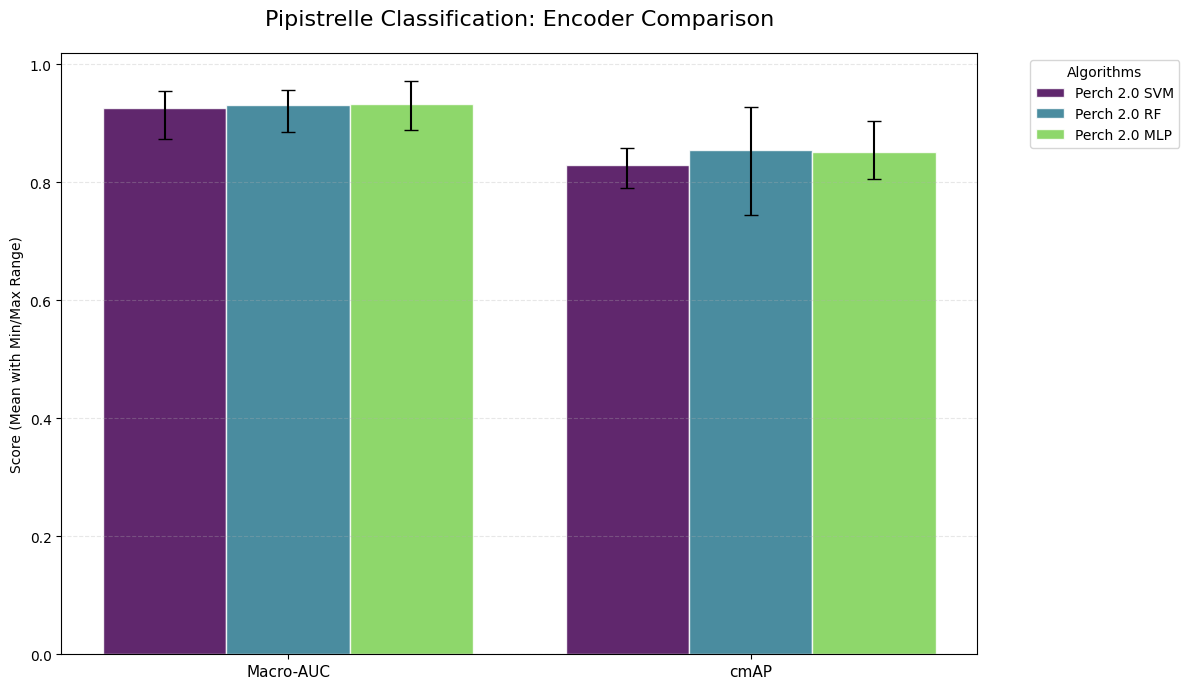

In [30]:
labels = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
results_vault = {
    "Perch 2.0 SVM": compute_cv_stats(y_true, y_pred_svm, label_names=labels),
    "Perch 2.0 RF": compute_cv_stats(y_true, y_pred_rf, label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true, y_pred_mlp, label_names=labels),
    }

# 2. Call the plot
plot_model_comparison(
    all_results=results_vault, 
    metrics_to_plot=['Macro-AUC', 'cmAP'], # Choose which metrics to show
    title="Pipistrelle Classification: Encoder Comparison"
)

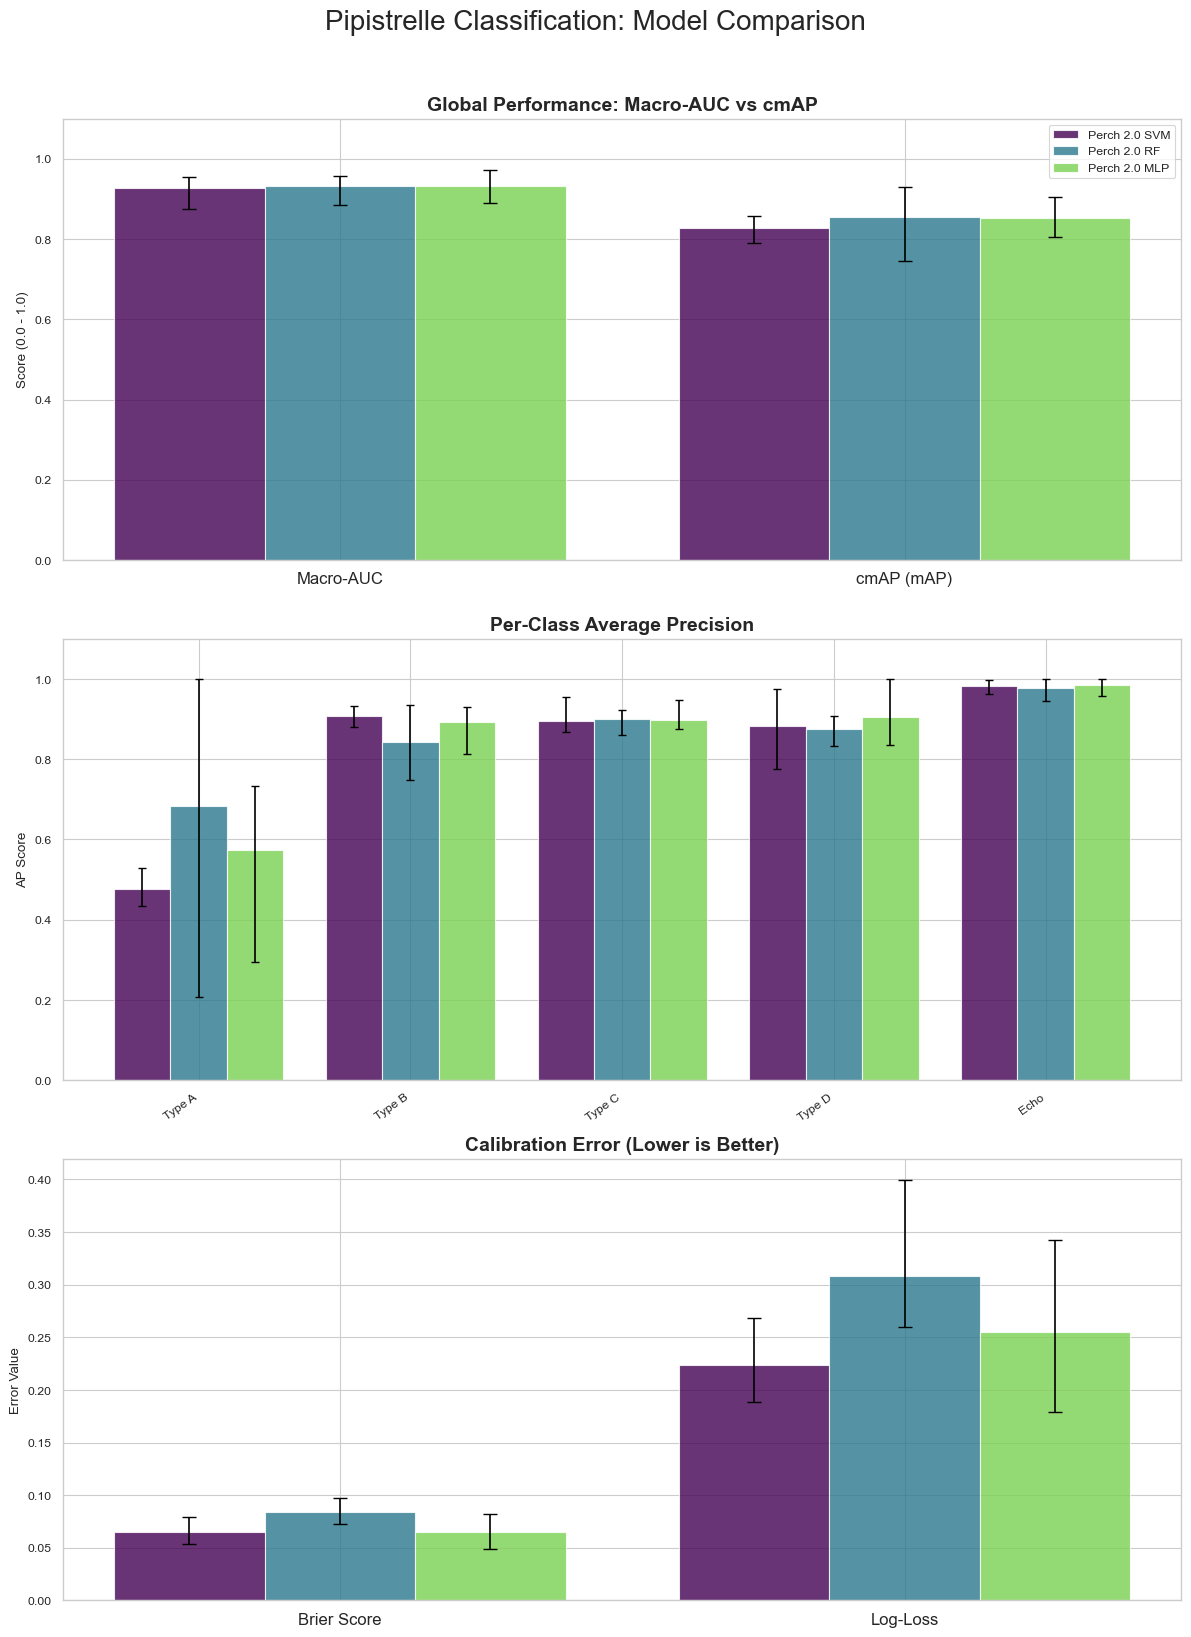

In [31]:
from evaluation.metrics import plot_comprehensive_results,generate_metrics_table

plot_comprehensive_results(results_vault, labels=label_names, title="Pipistrelle Classification: Model Comparison")

In [32]:

generate_metrics_table(results_vault,labels)[1]

,Model,AP type A,AP type B,AP type C,AP type D,AP Echo
0,Perch 2.0 SVM,0.476 ± 0.052,0.906 ± 0.027,0.895 ± 0.060,0.883 ± 0.107,0.983 ± 0.020
1,Perch 2.0 RF,0.683 ± 0.476,0.844 ± 0.095,0.899 ± 0.040,0.875 ± 0.041,0.978 ± 0.034
2,Perch 2.0 MLP,0.573 ± 0.278,0.893 ± 0.081,0.899 ± 0.049,0.906 ± 0.094,0.986 ± 0.027


In [33]:
generate_metrics_table(results_vault,labels)[0]

,Model,Macro-AUC,cmAP,Brier Score,Log-Loss
0,Perch 2.0 SVM,0.927 ± 0.052,0.829 ± 0.039,0.0646 ± 0.015,0.224 ± 0.045
1,Perch 2.0 RF,0.931 ± 0.045,0.856 ± 0.111,0.0841 ± 0.013,0.308 ± 0.091
2,Perch 2.0 MLP,0.933 ± 0.043,0.851 ± 0.053,0.0650 ± 0.017,0.255 ± 0.087


In [100]:
y_true_eff,y_pred_eff = linear_probe(pool_features(X_eff0, windows=False,window_pooled=True, method='mean', encoder='effnetb0'),y,n_split = 5,balance=False)
y_true_NLM,y_pred_NLM = linear_probe(pool_features(X_NLM, windows=False,window_pooled=True, method='mean', encoder='NLM_BEATs'),y,n_split = 5,balance=False)
y_true_perch,y_pred_perch = linear_probe(X_per2,y,n_split = 5,balance=False)

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...


In [101]:
labels = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
results_vault = {
    "Perch 2.0 SVM": compute_cv_stats(y_true_perch, y_pred_perch['SVM'], label_names=labels),
    "Perch 2.0 RF": compute_cv_stats(y_true_perch, y_pred_perch['Random Forest'], label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true_perch, y_pred_perch['MLP'], label_names=labels),

    "Effnetb0 SVM": compute_cv_stats(y_true_eff, y_pred_eff['SVM'], label_names=labels),
    "Effnetb0 RF": compute_cv_stats(y_true_eff, y_pred_eff['Random Forest'], label_names=labels),
    "Effnetb0 MLP": compute_cv_stats(y_true_eff, y_pred_eff['MLP'], label_names=labels),

    "NLM_BEATs SVM": compute_cv_stats(y_true_NLM, y_pred_NLM['SVM'], label_names=labels),
    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
    }



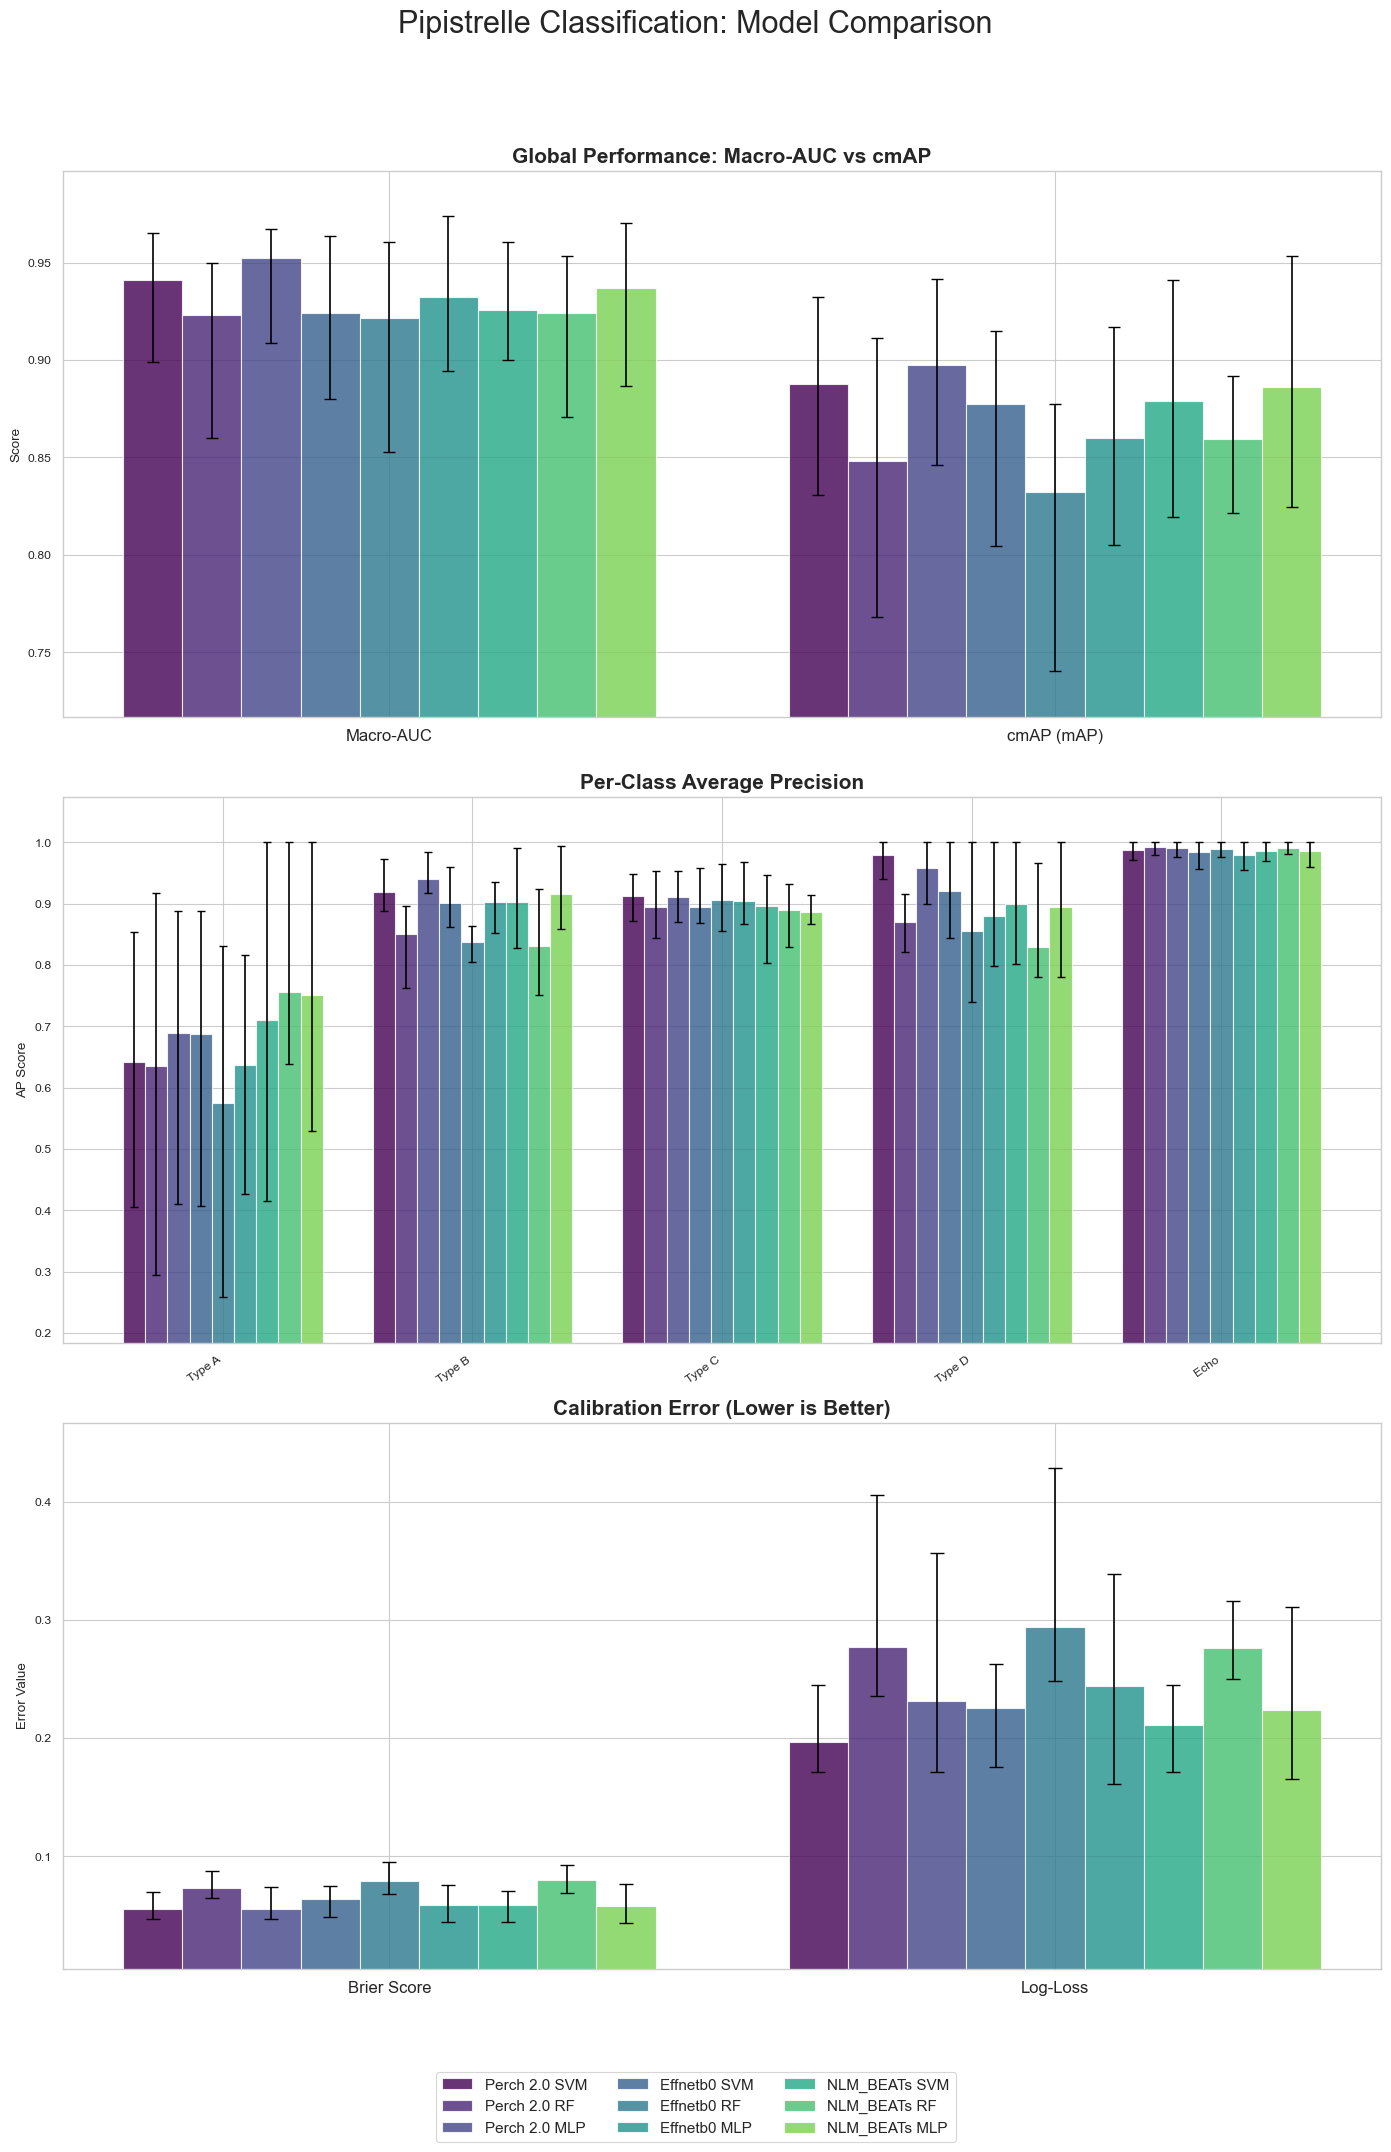

In [44]:
from evaluation.metrics import plot_comprehensive_results2
plot_comprehensive_results2(results_vault, labels=label_names, title="Pipistrelle Classification: Model Comparison")

In [45]:
generate_metrics_table(results_vault,labels)[0]

,Model,Macro-AUC,cmAP,Brier Score,Log-Loss
0,Perch 2.0 SVM,0.941 ± 0.042,0.888 ± 0.057,0.0555 ± 0.014,0.197 ± 0.048
1,Perch 2.0 RF,0.923 ± 0.063,0.848 ± 0.080,0.0735 ± 0.014,0.277 ± 0.128
2,Perch 2.0 MLP,0.952 ± 0.043,0.897 ± 0.051,0.0556 ± 0.019,0.231 ± 0.126
3,Effnetb0 SVM,0.924 ± 0.044,0.877 ± 0.073,0.0638 ± 0.015,0.226 ± 0.050
4,Effnetb0 RF,0.921 ± 0.069,0.832 ± 0.092,0.0787 ± 0.016,0.294 ± 0.135
5,Effnetb0 MLP,0.932 ± 0.042,0.860 ± 0.057,0.0590 ± 0.017,0.244 ± 0.095
6,NLM_BEATs SVM,0.926 ± 0.035,0.879 ± 0.062,0.0591 ± 0.014,0.211 ± 0.040
7,NLM_BEATs RF,0.924 ± 0.053,0.859 ± 0.038,0.0802 ± 0.013,0.276 ± 0.040
8,NLM_BEATs MLP,0.937 ± 0.050,0.886 ± 0.067,0.0580 ± 0.018,0.224 ± 0.087


In [46]:
generate_metrics_table(results_vault,labels)[1]

,Model,AP type A,AP type B,AP type C,AP type D,AP Echo
0,Perch 2.0 SVM,0.642 ± 0.237,0.919 ± 0.054,0.912 ± 0.041,0.980 ± 0.039,0.987 ± 0.016
1,Perch 2.0 RF,0.636 ± 0.341,0.850 ± 0.087,0.894 ± 0.059,0.869 ± 0.048,0.992 ± 0.013
2,Perch 2.0 MLP,0.689 ± 0.278,0.941 ± 0.043,0.910 ± 0.042,0.957 ± 0.059,0.990 ± 0.014
3,Effnetb0 SVM,0.688 ± 0.281,0.901 ± 0.058,0.894 ± 0.064,0.921 ± 0.079,0.983 ± 0.027
4,Effnetb0 RF,0.575 ± 0.317,0.837 ± 0.032,0.905 ± 0.059,0.854 ± 0.146,0.988 ± 0.012
5,Effnetb0 MLP,0.636 ± 0.210,0.902 ± 0.051,0.904 ± 0.065,0.880 ± 0.120,0.978 ± 0.024
6,NLM_BEATs SVM,0.711 ± 0.295,0.903 ± 0.087,0.896 ± 0.094,0.900 ± 0.100,0.985 ± 0.015
7,NLM_BEATs RF,0.756 ± 0.244,0.831 ± 0.092,0.890 ± 0.060,0.830 ± 0.136,0.990 ± 0.010
8,NLM_BEATs MLP,0.750 ± 0.250,0.916 ± 0.078,0.886 ± 0.028,0.894 ± 0.114,0.986 ± 0.026


In [102]:
y_true_effb,y_pred_effb = linear_probe(pool_features(X_eff0, windows=False,window_pooled=True, method='mean', encoder='effnetb0'),y,balance=True)
y_true_NLMb,y_pred_NLMb = linear_probe(pool_features(X_NLM, windows=False,window_pooled=True, method='mean', encoder='NLM_BEATs'),y,balance=True)
y_true_perchb,y_pred_perchb = linear_probe(X_per2,y,balance=True)

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...


In [103]:
labels = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
results_vault2 = {
    "Perch 2.0 SVM balanced": compute_cv_stats(y_true_perchb, y_pred_perchb['SVM'], label_names=labels),
    "Perch 2.0 RF balanced": compute_cv_stats(y_true_perchb, y_pred_perchb['Random Forest'], label_names=labels),
    "Perch 2.0 MLP balanced": compute_cv_stats(y_true_perchb, y_pred_perchb['MLP'], label_names=labels),

    "Effnetb0 SVM balanced": compute_cv_stats(y_true_effb, y_pred_effb['SVM'], label_names=labels),
    "Effnetb0 RF balanced": compute_cv_stats(y_true_effb, y_pred_effb['Random Forest'], label_names=labels),
    "Effnetb0 MLP balanced": compute_cv_stats(y_true_effb, y_pred_effb['MLP'], label_names=labels),

    "NLM_BEATs SVM balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['SVM'], label_names=labels),
    "NLM_BEATs RF balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['Random Forest'], label_names=labels),
    "NLM_BEATs MLP balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['MLP'], label_names=labels),

    "Perch 2.0 SVM": compute_cv_stats(y_true_perch, y_pred_perch['SVM'], label_names=labels),
    "Perch 2.0 RF": compute_cv_stats(y_true_perch, y_pred_perch['Random Forest'], label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true_perch, y_pred_perch['MLP'], label_names=labels),

    "Effnetb0 SVM": compute_cv_stats(y_true_eff, y_pred_eff['SVM'], label_names=labels),
    "Effnetb0 RF": compute_cv_stats(y_true_eff, y_pred_eff['Random Forest'], label_names=labels),
    "Effnetb0 MLP": compute_cv_stats(y_true_eff, y_pred_eff['MLP'], label_names=labels),

    "NLM_BEATs SVM": compute_cv_stats(y_true_NLM, y_pred_NLM['SVM'], label_names=labels),
    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
    }


In [105]:
results_vault2 = {
    "NLM_BEATs SVM balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['SVM'], label_names=labels),
    "NLM_BEATs RF balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['Random Forest'], label_names=labels),
    "NLM_BEATs MLP balanced": compute_cv_stats(y_true_NLMb, y_pred_NLMb['MLP'], label_names=labels),
    "NLM_BEATs SVM": compute_cv_stats(y_true_NLM, y_pred_NLM['SVM'], label_names=labels),
    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
    }


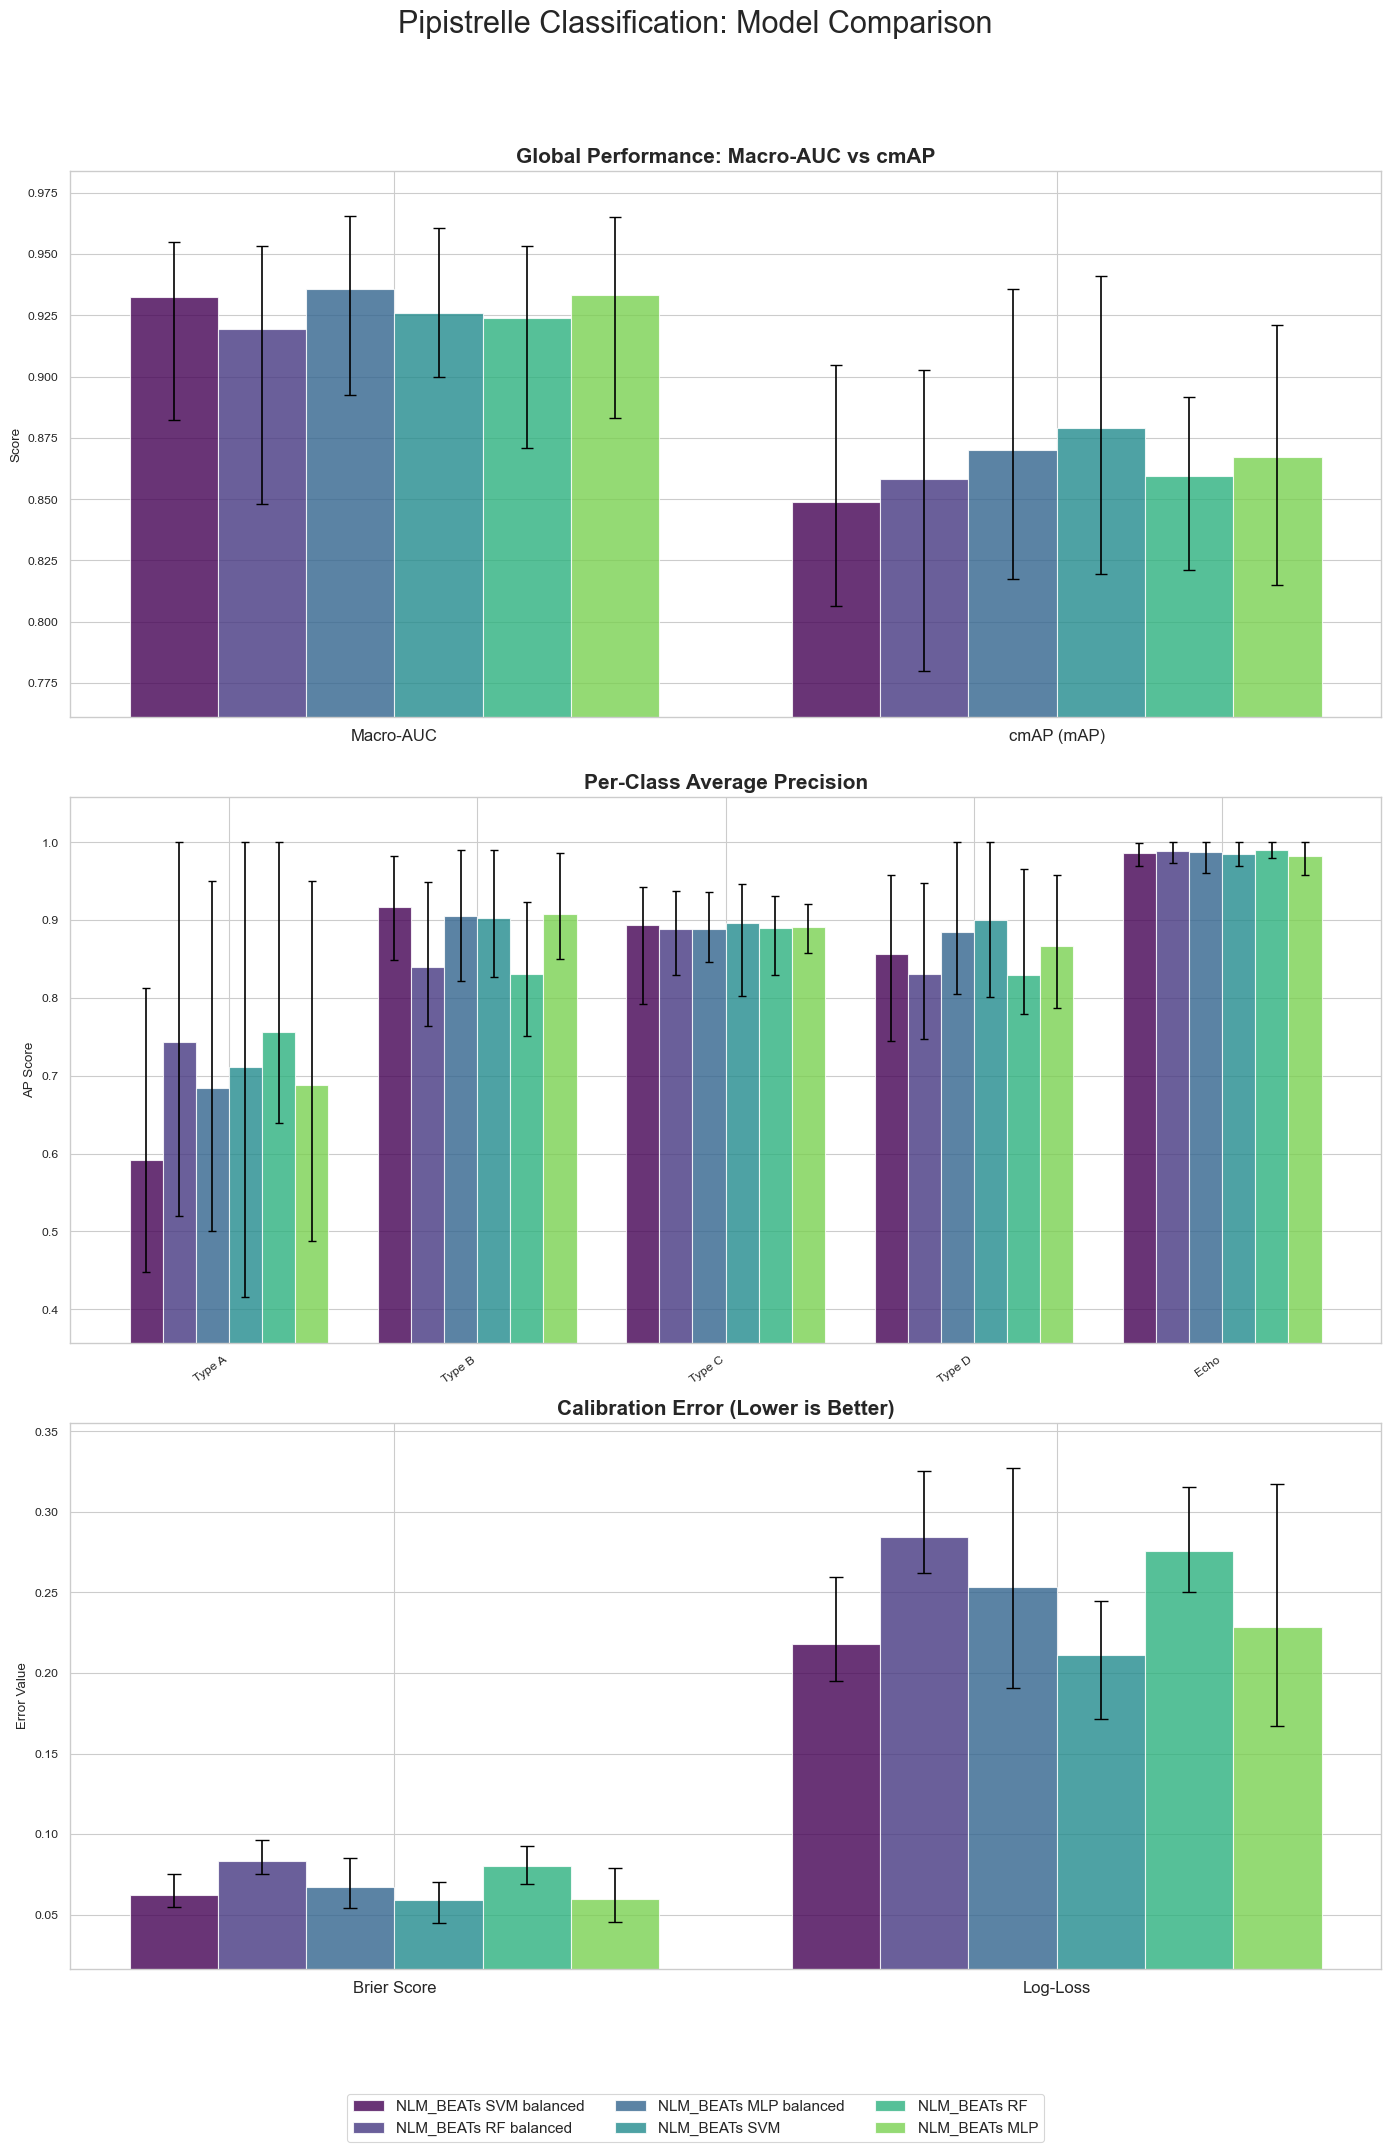

In [106]:
plot_comprehensive_results2(results_vault2, labels=label_names, title="Pipistrelle Classification: Model Comparison")

In [56]:
from preprocessing.dataset import AugmentationPipeline
aug_pipeline = AugmentationPipeline() 
X_aug,y_aug = aug_pipeline.iterative_oversample(X_eff0, y)

Final counts: [236 236 266 236 477]


In [107]:
y_true_eff_o,y_pred_eff_o = linear_probe(pool_features(X_eff0, windows=False,window_pooled=True, method='mean', encoder='effnetb0'),y,n_split = 5,balance=False,oversample=True)
y_true_NLM_o,y_pred_NLM_o = linear_probe(pool_features(X_NLM, windows=False,window_pooled=True, method='mean', encoder='NLM_BEATs'),y,n_split = 5,balance=False,oversample=True)
y_true_perch_o,y_pred_perch_o = linear_probe(X_per2,y,n_split = 5,balance=False,oversample=True)

Processing Fold 1...
Final counts: [189 189 217 189 397]
Processing Fold 2...
Final counts: [189 189 234 189 409]
Processing Fold 3...
Final counts: [189 189 228 189 393]
Processing Fold 4...
Final counts: [188 188 216 188 373]
Processing Fold 5...
Final counts: [189 189 195 189 400]
Processing Fold 1...
Final counts: [189 189 235 189 396]
Processing Fold 2...
Final counts: [189 189 215 189 402]
Processing Fold 3...
Final counts: [189 189 204 189 375]
Processing Fold 4...
Final counts: [188 188 225 188 369]
Processing Fold 5...
Final counts: [189 189 211 189 390]
Processing Fold 1...
Final counts: [189 189 229 189 395]
Processing Fold 2...
Final counts: [189 189 212 189 403]
Processing Fold 3...
Final counts: [189 189 236 189 389]
Processing Fold 4...
Final counts: [188 188 211 188 382]
Processing Fold 5...
Final counts: [189 189 209 189 397]


In [76]:
print(len(y_pred_perch_o['SVM'][2]))
print(len(y_pred_perch['SVM'][2]))

28
57


In [108]:
results_vault3 = {
    "Perch 2.0 SVM oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['SVM'], label_names=labels),
    "Perch 2.0 RF oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['Random Forest'], label_names=labels),
    "Perch 2.0 MLP oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['MLP'], label_names=labels),

    "Effnetb0 SVM oversampled": compute_cv_stats(y_true_eff_o, y_pred_eff_o['SVM'], label_names=labels),
    "Effnetb0 RF oversampled": compute_cv_stats(y_true_eff_o, y_pred_eff_o['Random Forest'], label_names=labels),
    "Effnetb0 MLP oversampled": compute_cv_stats(y_true_eff_o, y_pred_eff_o['MLP'], label_names=labels),

    "NLM_BEATs SVM oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['SVM'], label_names=labels),
    "NLM_BEATs RF oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['Random Forest'], label_names=labels),
    "NLM_BEATs MLP oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['MLP'], label_names=labels),

    "Perch 2.0 SVM": compute_cv_stats(y_true_perch, y_pred_perch['SVM'], label_names=labels),
    "Perch 2.0 RF": compute_cv_stats(y_true_perch, y_pred_perch['Random Forest'], label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true_perch, y_pred_perch['MLP'], label_names=labels),

    "Effnetb0 SVM": compute_cv_stats(y_true_eff, y_pred_eff['SVM'], label_names=labels),
    "Effnetb0 RF": compute_cv_stats(y_true_eff, y_pred_eff['Random Forest'], label_names=labels),
    "Effnetb0 MLP": compute_cv_stats(y_true_eff, y_pred_eff['MLP'], label_names=labels),

    "NLM_BEATs SVM": compute_cv_stats(y_true_NLM, y_pred_NLM['SVM'], label_names=labels),
    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
    }

In [110]:
results_vault4 = {
    "Perch 2.0 SVM oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['SVM'], label_names=labels),
    "Perch 2.0 RF oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['Random Forest'], label_names=labels),
    "Perch 2.0 MLP oversampled": compute_cv_stats(y_true_perch_o, y_pred_perch_o['MLP'], label_names=labels),

    "Perch 2.0 SVM": compute_cv_stats(y_true_perch, y_pred_perch['SVM'], label_names=labels),
    "Perch 2.0 RF": compute_cv_stats(y_true_perch, y_pred_perch['Random Forest'], label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true_perch, y_pred_perch['MLP'], label_names=labels),

    "NLM_BEATs SVM oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['SVM'], label_names=labels),
    "NLM_BEATs RF oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['Random Forest'], label_names=labels),
    "NLM_BEATs MLP oversampled": compute_cv_stats(y_true_NLM_o, y_pred_NLM_o['MLP'], label_names=labels),

    "NLM_BEATs SVM": compute_cv_stats(y_true_NLM, y_pred_NLM['SVM'], label_names=labels),
    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
    }

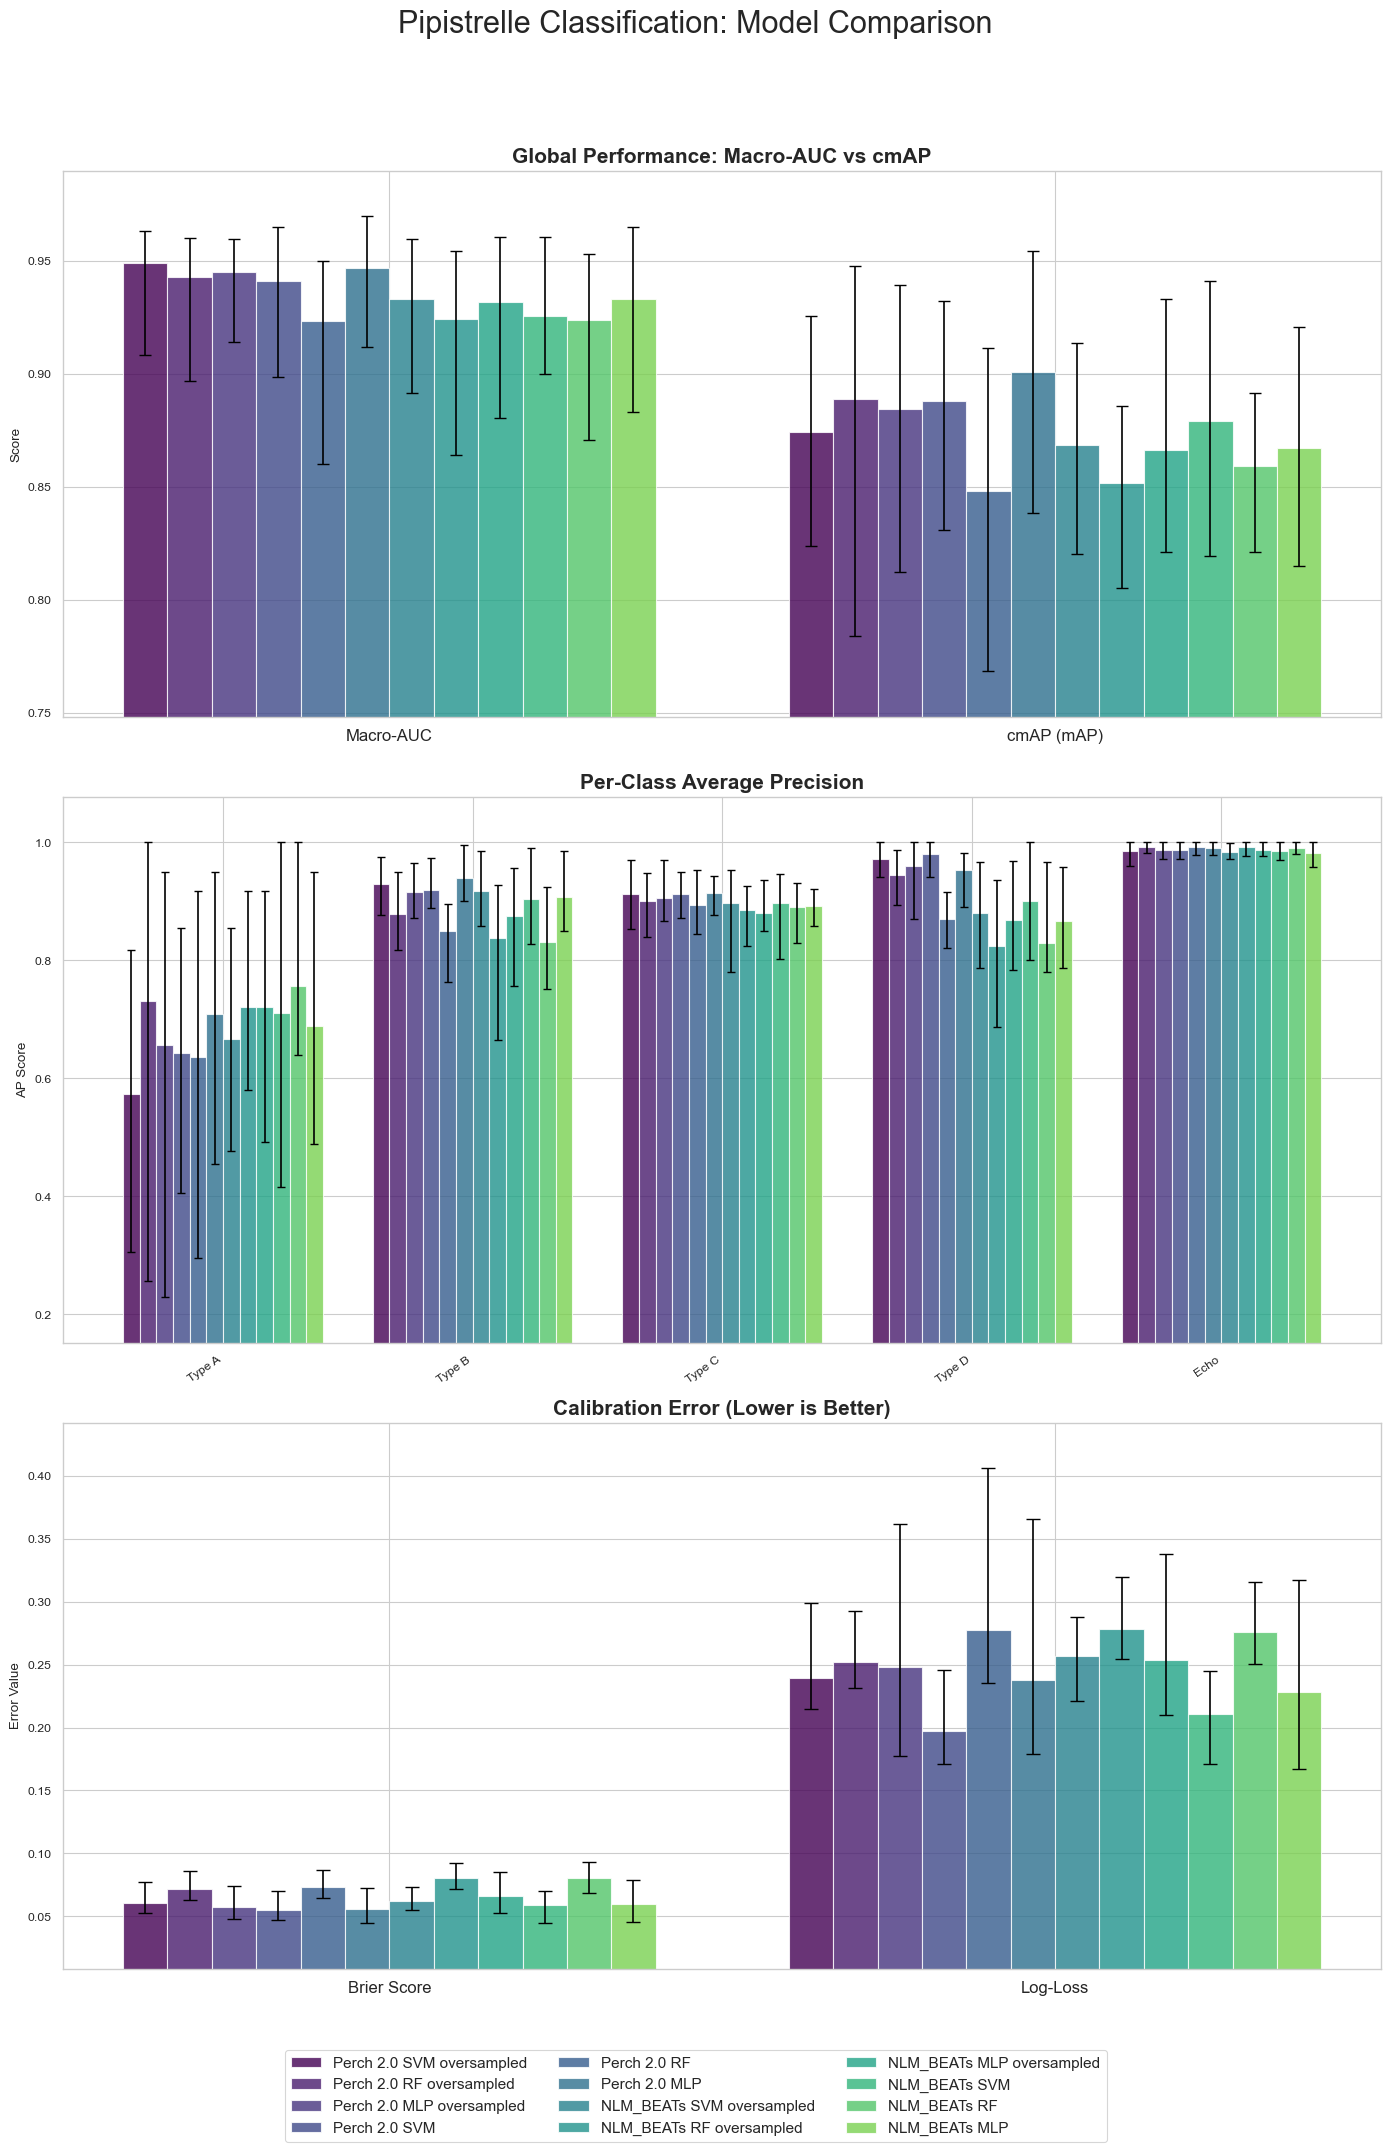

In [111]:
plot_comprehensive_results2(results_vault4, labels=label_names, title="Pipistrelle Classification: Model Comparison")

In [113]:
y_true_eff1,y_pred_eff1 = linear_probe(pool_features(X_eff0, windows=False,window_pooled=True, method='mean', encoder='effnetb0'),y,n_split = 5,balance=False)
y_true_NLM1,y_pred_NLM1 = linear_probe(pool_features(X_NLM, windows=False,window_pooled=True, method='mean', encoder='NLM_BEATs'),y,n_split = 5,balance=False)
y_true_perch1,y_pred_perch1 = linear_probe(X_per2,y,n_split = 5,balance=False)

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...


In [114]:
results_vault5 = {
    "Perch 2.0 RF OvR": compute_cv_stats(y_true_perch1, y_pred_perch1['Random Forest'], label_names=labels),
    "Perch 2.0 MLP OvR": compute_cv_stats(y_true_perch1, y_pred_perch1['MLP'], label_names=labels),

    "Perch 2.0 RF": compute_cv_stats(y_true_perch, y_pred_perch['Random Forest'], label_names=labels),
    "Perch 2.0 MLP": compute_cv_stats(y_true_perch, y_pred_perch['MLP'], label_names=labels),

    "NLM_BEATs RF OvR": compute_cv_stats(y_true_NLM1, y_pred_NLM1['Random Forest'], label_names=labels),
    "NLM_BEATs MLP OvR": compute_cv_stats(y_true_NLM1, y_pred_NLM1['MLP'], label_names=labels),

    "NLM_BEATs RF": compute_cv_stats(y_true_NLM, y_pred_NLM['Random Forest'], label_names=labels),
    "NLM_BEATs MLP": compute_cv_stats(y_true_NLM, y_pred_NLM['MLP'], label_names=labels),
}

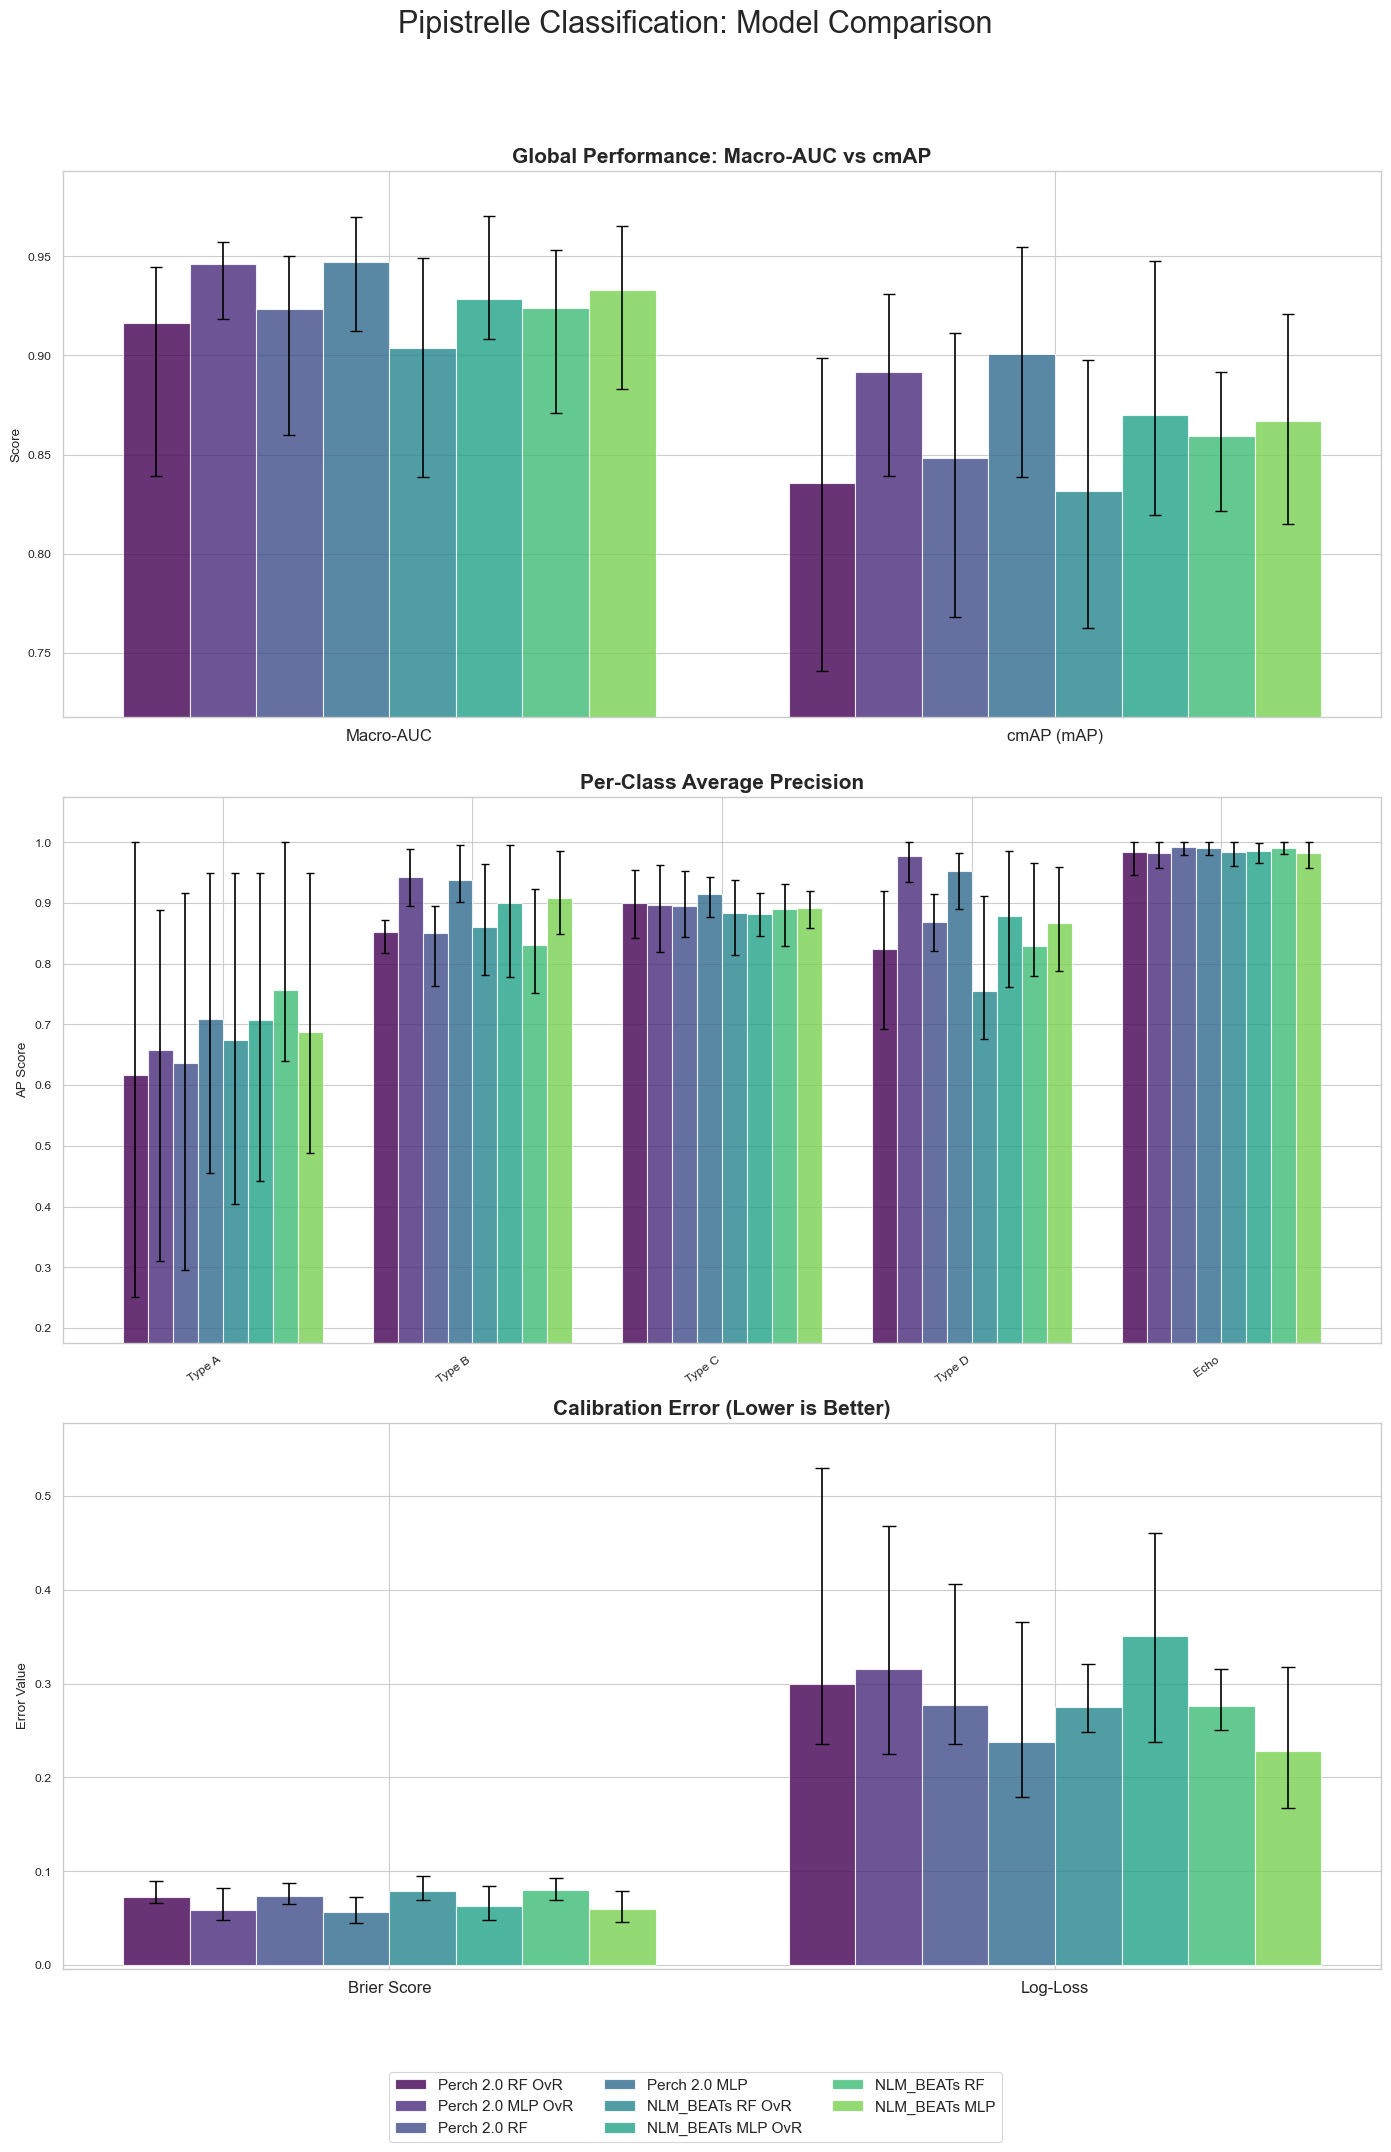

In [115]:
plot_comprehensive_results2(results_vault5, labels=label_names, title="Pipistrelle Classification: Model Comparison")

In [128]:
df = label_confusion(np.concatenate(y_true_NLM,axis=0),np.concatenate(y_pred_NLM['Random Forest'],axis=0),y_pred_binary=None, label_names=label_names, threshold=0.5)

In [129]:
print(df)

        Type A  Type B  Type C  Type D  Echo
Type A     0.0     3.0     0.0     0.0   5.0
Type B     0.0     0.0     8.0     0.0   0.0
Type C     0.0     4.0     0.0     0.0   4.0
Type D     0.0     0.0     9.0     0.0   1.0
Echo       0.0     0.0     0.0     0.0   0.0


In [123]:
#print(y_pred_NLM['Random Forest'][0])
print(y_true_NLM[0])

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [1. 1. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 0. 0. 1. 1.]
 [0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 1. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 1. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 0. 0. 1. 1.]
 [1. 0. 0.